# 01. Dataset Loading & Verification
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook loads all benchmark datasets, verifies class imbalance ratios, and saves them as standardized CSV files for downstream experiments.

| # | Dataset | Source | IR Range |
|---|---------|--------|----------|
| 1 | Default of Credit Card Clients | UCI | Low (~3.5) |
| 2 | Credit Card Fraud Detection | Kaggle/ULB | Extreme (~580) |
| 3 | Pima Indians Diabetes | UCI | Low (~1.9) |
| 4 | IBM HR Analytics Attrition | Kaggle | Low (~5.2) |
| 5 | Yeast ME2 | imbalanced-learn | Medium (~28) |
| 6 | Mammography | imbalanced-learn | High (~42) |
| 7 | Abalone-19 | imbalanced-learn | Extreme (~130) |
| 8 | Wine Quality | imbalanced-learn | Medium (~26) |
| 9 | Ecoli | imbalanced-learn | Medium (~8.6) |
| 10 | PageBlocks | OpenML | Medium |
| 11 | Protein Homo | imbalanced-learn | Extreme (~111) |


## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────
DATASET_DIR = "./datasets"
os.makedirs(DATASET_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Dataset directory : {os.path.abspath(DATASET_DIR)}")
print(f"Random state      : {RANDOM_STATE}")


Dataset directory : C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\10_GA_G_CTGAG\datasets
Random state      : 42


## 1. Load Datasets

### 1-1. imbalanced-learn built-in datasets

In [2]:
from imblearn.datasets import fetch_datasets

IMBLEARN_TARGETS = {
    "yeast_me2"   : "Yeast ME2",
    "mammography" : "Mammography",
    "abalone_19"  : "Abalone-19",
    "wine_quality": "Wine Quality",
    "ecoli"       : "Ecoli",
    "protein_homo": "Protein Homo",
}

print("Fetching imbalanced-learn datasets (download on first run)...")
all_ds = fetch_datasets()

imblearn_dfs = {}
for key, label in IMBLEARN_TARGETS.items():
    ds = all_ds[key]
    X, y = ds.data, ds.target
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df["target"] = (y == 1).astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, f"{key}.csv")
    df.to_csv(path, index=False)
    imblearn_dfs[key] = df

    print(f"  ✓ {label:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  → saved")


Fetching imbalanced-learn datasets (download on first run)...
  ✓ Yeast ME2             n=  1,484  minority=   51  IR=   28.1  → saved
  ✓ Mammography           n= 11,183  minority=  260  IR=   42.0  → saved
  ✓ Abalone-19            n=  4,177  minority=   32  IR=  129.5  → saved
  ✓ Wine Quality          n=  4,898  minority=  183  IR=   25.8  → saved
  ✓ Ecoli                 n=    336  minority=   35  IR=    8.6  → saved
  ✓ Protein Homo          n=145,751  minority=1,296  IR=  111.5  → saved


### 1-2. OpenML — PageBlocks

In [3]:
import openml

OPENML_TARGETS = [
    (30, "pageblocks", "PageBlocks"),
]

openml_dfs = {}
for ds_id, key, label in OPENML_TARGETS:
    try:
        dataset = openml.datasets.get_dataset(ds_id)
        X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
        df = X.copy()
        y_s = pd.Series(y).astype(str)
        min_cls = y_s.value_counts().idxmin()
        df["target"] = (y_s == min_cls).astype(int)

        # Encode remaining categoricals
        cat_cols = df.select_dtypes(include="object").columns
        if len(cat_cols):
            df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

        minority = int(df["target"].sum())
        majority = len(df) - minority
        ir = round(majority / minority, 2)

        path = os.path.join(DATASET_DIR, f"{key}.csv")
        df.to_csv(path, index=False)
        openml_dfs[key] = df
        print(f"  ✓ {label:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  → saved")

    except Exception as e:
        print(f"  ✗ {label}  Error: {e}")


  ✓ PageBlocks            n=  5,473  minority=   28  IR=  194.5  → saved


### 1-3. UCI — Default of Credit Card Clients

In [4]:
from ucimlrepo import fetch_ucirepo

uci_dfs = {}
try:
    ds = fetch_ucirepo(id=350)
    X, y = ds.data.features, ds.data.targets
    df = pd.concat([X, y], axis=1)
    df.columns = [*X.columns, "target"]
    df["target"] = df["target"].astype(int)

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, "credit_default.csv")
    df.to_csv(path, index=False)
    uci_dfs["credit_default"] = df
    print(f"  ✓ {'Credit Default':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  → saved")

except Exception as e:
    print(f"  ✗ Credit Default  Error: {e}")
    print("    Manual download: https://archive.ics.uci.edu/dataset/350")


  ✓ Credit Default        n= 30,000  minority=6,636  IR=    3.5  → saved


### 1-4. Kaggle — Fraud Detection & IBM HR Attrition

In [5]:
KAGGLE_DIR = r"C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\10_GA_G_CTGAG\kaggle"

KAGGLE_FILES = [
    {
        "key"   : "fraud_detection",
        "label" : "Credit Card Fraud",
        "file"  : "creditcard.csv",
        "target": "Class",
        "encode": False,
    },
    {
        "key"   : "ibm_attrition",
        "label" : "IBM HR Attrition",
        "file"  : "WA_Fn-UseC_-HR-Employee-Attrition.csv",
        "target": "Attrition",
        "encode": True,
    },
]

kaggle_dfs = {}
for cfg in KAGGLE_FILES:
    # Search order: datasets/ → KAGGLE_DIR
    candidates = [
        os.path.join(DATASET_DIR, cfg["file"]),
        os.path.join(KAGGLE_DIR,  cfg["file"]),
        os.path.join(DATASET_DIR, f"{cfg['key']}.csv"),
    ]
    src = next((p for p in candidates if os.path.exists(p)), None)

    if src is None:
        print(f"  ✗ {cfg['label']}  →  file not found: {cfg['file']}")
        continue

    df = pd.read_csv(src)

    if cfg["encode"]:
        df["target"] = (df[cfg["target"]] == "Yes").astype(int)
        df = df.drop(columns=[cfg["target"]])
        cat_cols = df.select_dtypes(include="object").columns
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    else:
        df = df.rename(columns={cfg["target"]: "target"})

    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)

    path = os.path.join(DATASET_DIR, f"{cfg['key']}.csv")
    df.to_csv(path, index=False)
    kaggle_dfs[cfg["key"]] = df
    print(f"  ✓ {cfg['label']:<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  → saved")


  ✓ Credit Card Fraud     n=284,807  minority=  492  IR=  577.9  → saved
  ✓ IBM HR Attrition      n=  1,470  minority=  237  IR=    5.2  → saved


### 1-5. Pima Indians Diabetes

In [6]:
pima_dfs = {}
# Try UCI repo first, then GitHub fallback
pima_path = os.path.join(DATASET_DIR, "pima_diabetes.csv")

if os.path.exists(pima_path):
    df = pd.read_csv(pima_path)
    if "Outcome" in df.columns:
        df = df.rename(columns={"Outcome": "target"})
    print("  ✓ Pima Diabetes (loaded from cache)")
else:
    try:
        ds = fetch_ucirepo(id=34)
        X, y = ds.data.features, ds.data.targets
        df = pd.concat([X, y], axis=1)
        df.columns = [*X.columns, "target"]
        df["target"] = df["target"].astype(int)
    except Exception:
        url = ("https://raw.githubusercontent.com/"
               "jbrownlee/Datasets/master/pima-indians-diabetes.data.csv")
        cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                "Insulin","BMI","DiabetesPedigreeFunction","Age","target"]
        df = pd.read_csv(url, header=None, names=cols)

minority = int(df["target"].sum())
majority = len(df) - minority
ir = round(majority / minority, 2)

df.to_csv(pima_path, index=False)
pima_dfs["pima_diabetes"] = df
print(f"  ✓ {'Pima Diabetes':<20}  n={len(df):>7,}  minority={minority:>5,}  IR={ir:>7.1f}  → saved")


  ✓ Pima Diabetes (loaded from cache)
  ✓ Pima Diabetes         n=    768  minority=  268  IR=    1.9  → saved


## 2. Dataset Summary

In [7]:
# Merge all loaded datasets
all_datasets = {}
for d in [imblearn_dfs, openml_dfs, uci_dfs, kaggle_dfs, pima_dfs]:
    all_datasets.update(d)

# Build summary table
IR_BINS = {
    "Low (IR < 10)"       : lambda ir: ir < 10,
    "Medium (10 ≤ IR < 50)": lambda ir: 10 <= ir < 50,
    "High (IR ≥ 50)"      : lambda ir: ir >= 50,
}

rows = []
for name, df in all_datasets.items():
    minority = int(df["target"].sum())
    majority = len(df) - minority
    ir = round(majority / minority, 2)
    n_features = df.shape[1] - 1
    ir_group = next(k for k, fn in IR_BINS.items() if fn(ir))

    rows.append({
        "Dataset"  : name,
        "Samples"  : len(df),
        "Features" : n_features,
        "Minority" : minority,
        "Majority" : majority,
        "IR"       : ir,
        "IR Group" : ir_group,
    })

summary = pd.DataFrame(rows).sort_values("IR").reset_index(drop=True)
summary.index += 1

print("=" * 75)
print("Dataset Summary")
print("=" * 75)
print(summary.to_string())
print("=" * 75)
print(f"Total datasets loaded: {len(summary)}")
print(f"IR groups  —  {summary['IR Group'].value_counts().to_dict()}")


Dataset Summary
            Dataset  Samples  Features  Minority  Majority      IR               IR Group
1     pima_diabetes      768         8       268       500    1.87          Low (IR < 10)
2    credit_default    30000        23      6636     23364    3.52          Low (IR < 10)
3     ibm_attrition     1470        47       237      1233    5.20          Low (IR < 10)
4             ecoli      336         7        35       301    8.60          Low (IR < 10)
5      wine_quality     4898        11       183      4715   25.77  Medium (10 ≤ IR < 50)
6         yeast_me2     1484         8        51      1433   28.10  Medium (10 ≤ IR < 50)
7       mammography    11183         6       260     10923   42.01  Medium (10 ≤ IR < 50)
8      protein_homo   145751        74      1296    144455  111.46         High (IR ≥ 50)
9        abalone_19     4177        10        32      4145  129.53         High (IR ≥ 50)
10       pageblocks     5473        10        28      5445  194.46         High (IR 

## 3. Visualization

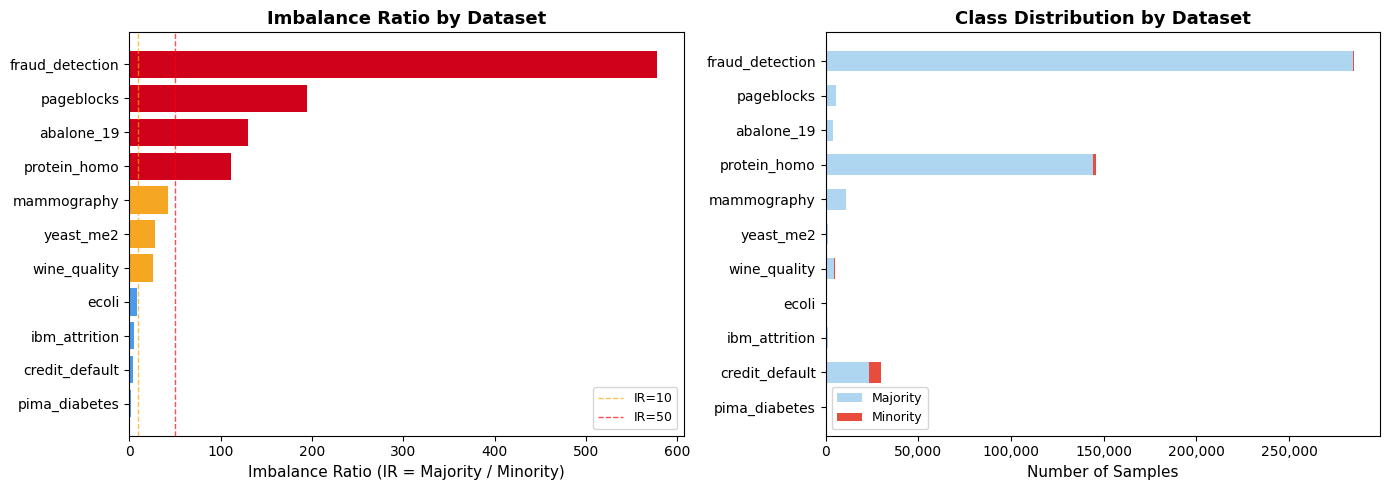

Figure saved → ./results/01_dataset_summary.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: IR bar chart ───────────────────────────────────
colors = {
    "Low (IR < 10)"       : "#4C9BE8",
    "Medium (10 ≤ IR < 50)": "#F5A623",
    "High (IR ≥ 50)"      : "#D0021B",
}
bar_colors = [colors[g] for g in summary["IR Group"]]

axes[0].barh(summary["Dataset"], summary["IR"], color=bar_colors)
axes[0].set_xlabel("Imbalance Ratio (IR = Majority / Minority)", fontsize=11)
axes[0].set_title("Imbalance Ratio by Dataset", fontsize=13, fontweight="bold")
axes[0].axvline(10,  color="orange", linestyle="--", linewidth=1, alpha=0.7, label="IR=10")
axes[0].axvline(50,  color="red",    linestyle="--", linewidth=1, alpha=0.7, label="IR=50")
axes[0].legend(fontsize=9)

# ── Plot 2: Class distribution stacked bar ─────────────────
bar_width = 0.6
indices = range(len(summary))

axes[1].barh(summary["Dataset"], summary["Majority"],
             color="#AED6F1", label="Majority", height=bar_width)
axes[1].barh(summary["Dataset"], summary["Minority"],
             left=summary["Majority"],
             color="#E74C3C", label="Minority", height=bar_width)
axes[1].set_xlabel("Number of Samples", fontsize=11)
axes[1].set_title("Class Distribution by Dataset", fontsize=13, fontweight="bold")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(fontsize=9)

plt.tight_layout()
os.makedirs("./results", exist_ok=True)
plt.savefig("./results/01_dataset_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → ./results/01_dataset_summary.png")


## 4. Verification

In [9]:
print("Verifying saved CSV files...")
print()

all_ok = True
for name in all_datasets:
    path = os.path.join(DATASET_DIR, f"{name}.csv")
    if os.path.exists(path):
        df_check = pd.read_csv(path)
        assert "target" in df_check.columns, f"'target' column missing in {name}"
        assert df_check["target"].nunique() == 2, f"Non-binary target in {name}"
        print(f"  ✓ {name:<25}  shape={str(df_check.shape):<15}  target_values={sorted(df_check['target'].unique())}")
    else:
        print(f"  ✗ {name:<25}  FILE NOT FOUND")
        all_ok = False

print()
if all_ok:
    print("All datasets verified successfully. Ready for experiment notebooks.")
else:
    print("Some datasets are missing. Please re-run the loading cells above.")


Verifying saved CSV files...

  ✓ yeast_me2                  shape=(1484, 9)        target_values=[0, 1]
  ✓ mammography                shape=(11183, 7)       target_values=[0, 1]
  ✓ abalone_19                 shape=(4177, 11)       target_values=[0, 1]
  ✓ wine_quality               shape=(4898, 12)       target_values=[0, 1]
  ✓ ecoli                      shape=(336, 8)         target_values=[0, 1]
  ✓ protein_homo               shape=(145751, 75)     target_values=[0, 1]
  ✓ pageblocks                 shape=(5473, 11)       target_values=[0, 1]
  ✓ credit_default             shape=(30000, 24)      target_values=[0, 1]
  ✓ fraud_detection            shape=(284807, 31)     target_values=[0, 1]
  ✓ ibm_attrition              shape=(1470, 48)       target_values=[0, 1]
  ✓ pima_diabetes              shape=(768, 9)         target_values=[0, 1]

All datasets verified successfully. Ready for experiment notebooks.
